# CSCN8010: Statistical Classification and Logistic Regression

## Group 2 Assignment

**Instructor:** Professor [To be filled]
**Course:** CSCN8010 - Machine Learning Fundamentals
**Date:** [Assignment Date]
**Group Members (Collaborators):**

| Name | Role | Contribution |
| :--- | :--- | :--- |
| **Ali Cihan Ozdemir** | Lead Developer | Primary implementation, notebook structure, code development |
| **Lohith Reddy Danda** | Co-Developer | Documentation support, code review, testing assistance |
| **Roshan Bartaul** | Co-Developer | Research support, analysis questions, peer review coordination |

*This is a collaborative group project where all members contributed to the successful completion of the assignment.*

---

## 📋 Assignment Overview

This assignment covers the fundamental concepts of **Logistic Regression** as a statistical classification method. You will learn how to implement logistic regression from scratch, understand the mathematics behind it, and apply it to real-world binary classification problems.

### Learning Objectives

By completing this assignment, you will:

1. ✅ Understand the difference between linear regression and logistic regression
2. ✅ Implement the sigmoid function and understand its role in classification
3. ✅ Build a logistic regression model using scikit-learn
4. ✅ Evaluate model performance using various metrics (Accuracy, Precision, Recall, F1-Score)
5. ✅ Understand and implement the Log-Loss (Cross-Entropy) function
6. ✅ Visualize decision boundaries and model results

### Reference Repository

For additional resources and examples, please refer to the reference repository:
**GitHub:** [Reference Repository Link]

---

## 1. Linear Regression Recap

Before diving into logistic regression, let's briefly review **linear regression** - a method for predicting continuous values.

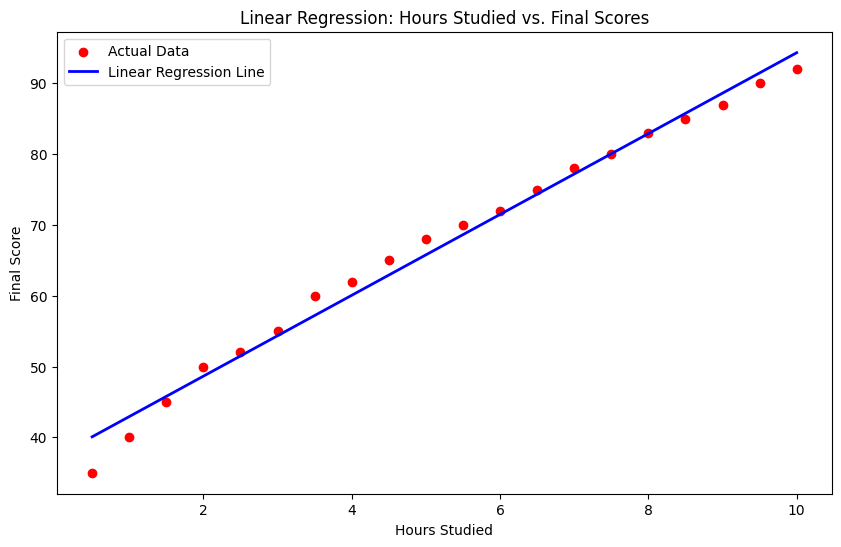

Model Coefficient: 5.71
Model Intercept: 37.22


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Sample data: Hours studied vs. Final scores
hours_studied = np.array([0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5, 5.5, 6, 6.5, 7, 7.5, 8, 8.5, 9, 9.5, 10]).reshape(-1, 1)
final_scores = np.array([35, 40, 45, 50, 52, 55, 60, 62, 65, 68, 70, 72, 75, 78, 80, 83, 85, 87, 90, 92])

# Fit a linear regression model
linear_model = LinearRegression()
linear_model.fit(hours_studied, final_scores)
predicted_scores = linear_model.predict(hours_studied)

# Scatter plot and regression line
plt.figure(figsize=(10, 6))
plt.scatter(hours_studied, final_scores, color='red', label='Actual Data')
plt.plot(hours_studied, predicted_scores, color='blue', linewidth=2, label='Linear Regression Line')
plt.xlabel('Hours Studied')
plt.ylabel('Final Score')
plt.title('Linear Regression: Hours Studied vs. Final Scores')
plt.legend()
plt.show()

print(f"Model Coefficient: {linear_model.coef_[0]:.2f}")
print(f"Model Intercept: {linear_model.intercept_:.2f}")

### Understanding Mean Squared Error (MSE) and R-squared

- **MSE** tells you the absolute magnitude of the model's prediction error. It answers:  
    *"On average, how far off are my predictions?"*

- **R-squared** tells you the relative explanatory power of the model. It answers:  
    *"How much of the real-world variation does my model actually capture?"*

In [2]:
from sklearn.metrics import mean_squared_error, r2_score

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(final_scores, predicted_scores)
print(f"Mean Squared Error (MSE): {mse:.2f}")

# Calculate R-squared
r2 = r2_score(final_scores, predicted_scores)
print(f"R-squared: {r2:.4f}")

print("\nInterpretation:")
print(f"- The MSE of {mse:.2f} indicates the average squared difference between the actual and predicted scores.")
print(f"- The R-squared value of {r2:.4f} shows that the model explains {r2*100:.2f}% of the variance in final scores based on hours studied.")

Mean Squared Error (MSE): 3.62
R-squared: 0.9868

Interpretation:
- The MSE of 3.62 indicates the average squared difference between the actual and predicted scores.
- The R-squared value of 0.9868 shows that the model explains 98.68% of the variance in final scores based on hours studied.


#### Summary of Key Differences

| Feature | Mean Squared Error (MSE) | R-squared (R²) |
| :--- | :--- | :--- |
| **Main Purpose** | Measures the average magnitude of prediction error. | Measures the proportion of variance explained by the model. |
| **Scale** | In **squared units** of the target variable (e.g., dollars², kg²). | **Unitless** (a ratio or percentage from 0 to 1). |
| **Interpretation** | Absolute measure of error. Lacks context without knowing the scale of the data. | Relative measure of fit. Provides context automatically. |
| **"Good" Value** | As close to **0** as possible. | As close to **1** as possible. |

---

## 2. From Linear to Logistic Regression

Now, let's explore the problem with using linear regression for **binary classification** (e.g., Pass/Fail).

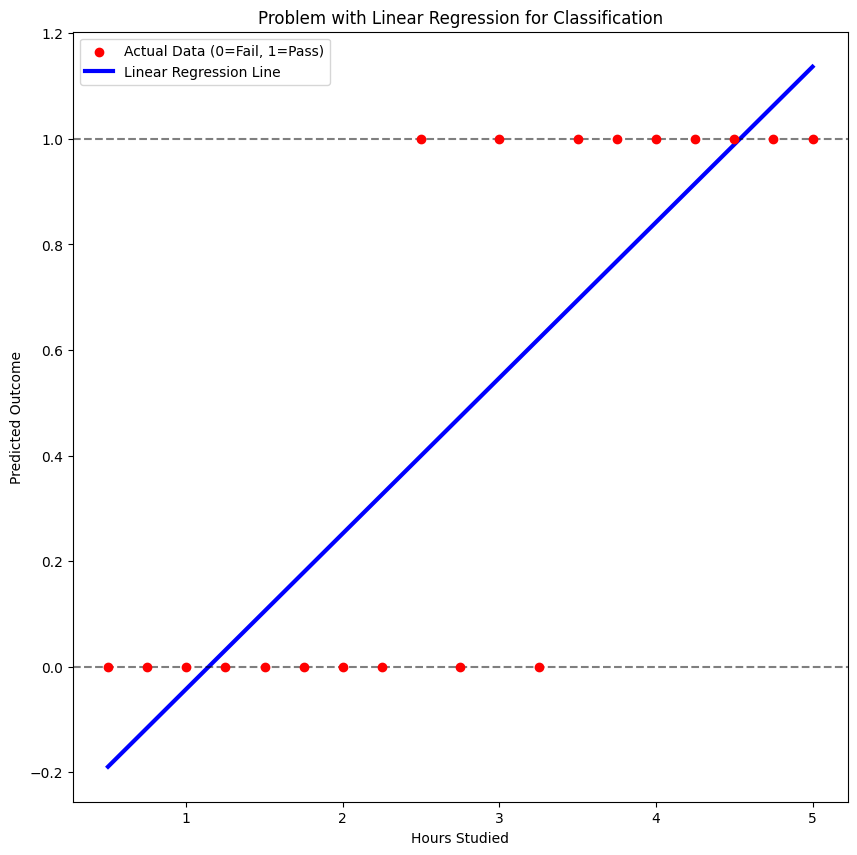

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Sample data: Hours studied vs. Pass/Fail
hours_studied = np.array([0.5, 0.75, 1, 1.25, 1.5, 1.75, 2, 2.25, 2.5, 2.75, 3, 3.25, 3.5, 3.75, 4, 4.25, 4.5, 4.75, 5]).reshape(-1, 1)
pass_fail = np.array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1])

# Fit a linear regression model
linear_model = LinearRegression()
linear_model.fit(hours_studied, pass_fail)
line = linear_model.predict(hours_studied)

# Plotting
plt.figure(figsize=(10, 10))
plt.scatter(hours_studied, pass_fail, color='red', zorder=20, label='Actual Data (0=Fail, 1=Pass)')
plt.plot(hours_studied, line, color='blue', linewidth=3, label='Linear Regression Line')
plt.xlabel('Hours Studied')
plt.ylabel('Predicted Outcome')
plt.title('Problem with Linear Regression for Classification')
plt.axhline(y=0, color='k', linestyle='--', alpha=0.5)
plt.axhline(y=1, color='k', linestyle='--', alpha=0.5)
plt.legend()
plt.show()

### ⚠️ The Problem

As you can see, linear regression produces values that can go below 0 or above 1, which doesn't make sense for probabilities! This is why we need **logistic regression**.

---

## 3. Introduction to Logistic Regression

**Logistic Regression** is a statistical method used for binary classification problems—where the goal is to assign each input to one of two possible categories. Unlike linear regression, which predicts continuous values, logistic regression predicts the probability that an input belongs to a particular class.

### The Logistic (Sigmoid) Function

At the heart of logistic regression is the **logistic function**, also known as the **sigmoid function**. This function takes any real-valued number and maps it to a value between 0 and 1, making it ideal for modeling probabilities.

The sigmoid function is defined as:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

where $z$ is the output of a linear equation:

$$
z = w_0 + w_1 x
$$

- $w_0$ is the intercept (bias)
- $w_1$ is the coefficient (weight)
- $x$ is the input feature (e.g., hours studied)

### From Probability to Classification

The output of the sigmoid function, $\sigma(z)$, represents the probability that the input belongs to the positive class (e.g., "Pass"). To make a final decision, we use a threshold—commonly 0.5:

- If $\sigma(z) \geq 0.5$, classify as **Pass** (1)
- If $\sigma(z) < 0.5$, classify as **Fail** (0)

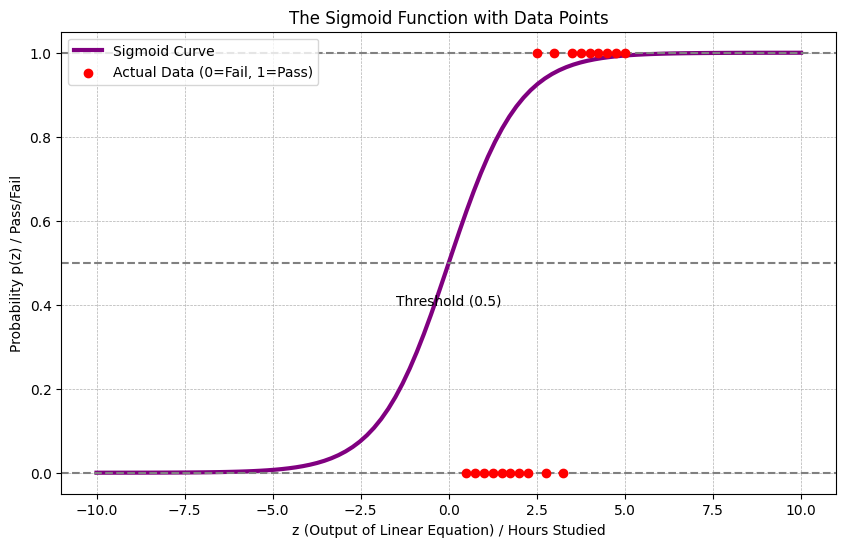

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Data for hours studied and pass/fail
hours_studied = np.array([0.5, 0.75, 1, 1.25, 1.5, 1.75, 2, 2.25, 2.5, 2.75, 3, 3.25, 3.5, 3.75, 4, 4.25, 4.5, 4.75, 5])
pass_fail = np.array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1])

z = np.linspace(-10, 10, 100)
p = sigmoid(z)

plt.figure(figsize=(10, 6))
plt.plot(z, p, color='purple', linewidth=3, label='Sigmoid Curve')
plt.scatter(hours_studied, pass_fail, color='red', zorder=20, label='Actual Data (0=Fail, 1=Pass)')
plt.xlabel('z (Output of Linear Equation) / Hours Studied')
plt.ylabel('Probability p(z) / Pass/Fail')
plt.title('The Sigmoid Function with Data Points')
plt.axhline(y=0.5, color='grey', linestyle='--')
plt.axhline(y=0, color='grey', linestyle='--')
plt.axhline(y=1, color='grey', linestyle='--')
plt.text(0, 0.4, 'Threshold (0.5)', ha='center')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()

No matter what the input ($z$) is, the output (the probability) is always between 0 and 1. This S-curve is what the model learns to fit to our data.

---

## 4. An Introduction to Statistical Classification

So, what exactly is **classification**? It's the process of taking an input and assigning it to a specific category or **class**.

Think of it as sorting. You're given a piece of fruit and you have to decide if it's an 'Apple', 'Banana', or 'Orange'. In machine learning, we build a model, called a **classifier**, to do this sorting for us automatically.

### Key Terminology
 - **Classifier**: The algorithm or model that performs the classification (e.g., Logistic Regression).
 - **Features**: The input variables used to make the decision. For our fruit example, features could be `color`, `shape`, and `weight`.
 - **Classes** (or Labels): The categories we are trying to predict (e.g., 'Apple', 'Banana', 'Orange').
 - **Decision Boundary**: An imaginary line or surface that separates the different classes. The classifier learns this boundary from the data.

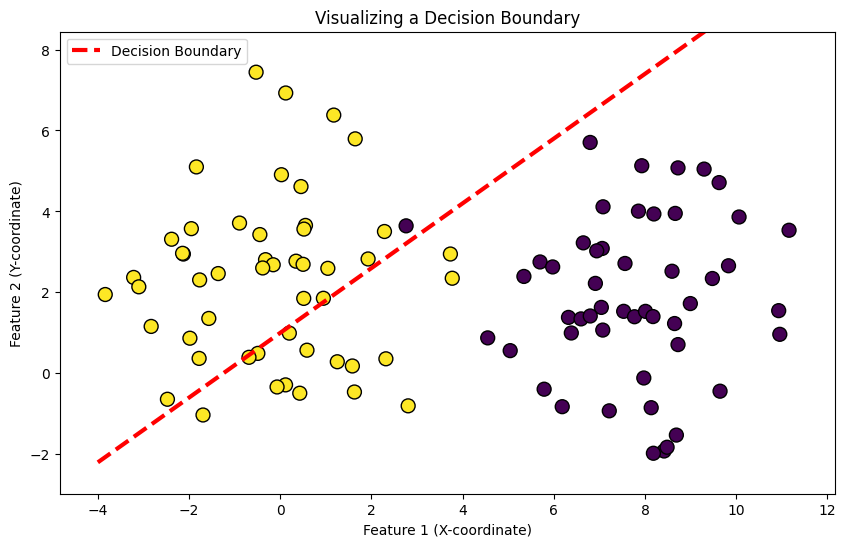

In [5]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

# Generate simple, linearly separable data
X, y = make_blobs(n_samples=100, centers=[(8, 2), (0, 2)], n_features=2, random_state=42, cluster_std=2)

# A simple decision boundary (we can just draw a line for this example)
x_decision = np.linspace(-4, 12, 100)
y_decision = 0.8 * x_decision + 1 # A manually chosen line for illustration

plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolor='k', s=100)
plt.plot(x_decision, y_decision, color='red', linestyle='--', linewidth=3, label='Decision Boundary')
plt.xlabel('Feature 1 (X-coordinate)')
plt.ylabel('Feature 2 (Y-coordinate)')
plt.title('Visualizing a Decision Boundary')
plt.legend()
plt.xlim(X[:, 0].min() - 1, X[:, 0].max() + 1)
plt.ylim(X[:, 1].min() - 1, X[:, 1].max() + 1)
plt.show()

In the plot above, the classifier's job is to find the best possible red dashed line to separate the purple dots from the yellow dots. Any new dot that falls on one side of the line will be classified as purple, and any dot on the other side will be classified as yellow. The machine learning algorithm's goal is to learn the optimal position for this line based on the training data.

---

## 5. Statistical Classification using Logistic Regression

Now, let's connect the two concepts. How do we get from the probabilities of Logistic Regression to a final classification like 'Pass' or 'Fail'?

### From Probability to Decision: The Threshold

We use a **decision threshold**. It's a simple rule:

> If the predicted probability from our sigmoid function is greater than or equal to a certain value (usually 0.5), we classify the sample as belonging to Class 1. Otherwise, we classify it as Class 0.

 - `p(X) >= 0.5`  ➡️  Classify as 1 (e.g., 'Pass', 'Is Obese', 'Spam')
 - `p(X) < 0.5`   ➡️  Classify as 0 (e.g., 'Fail', 'Is Not Obese', 'Not Spam')

That's it! The logistic regression model finds the best S-curve, and we use a 0.5 probability cutoff to make the final call.

Let's examine a student who studied for 2.6 hours:
Probability of Failing (Class 0) vs. Passing (Class 1): [0.60846302 0.39153698]
Since 0.39 is > 0.5, the final classification is: 0 (Pass)

Model Accuracy on the training data: 89.47%


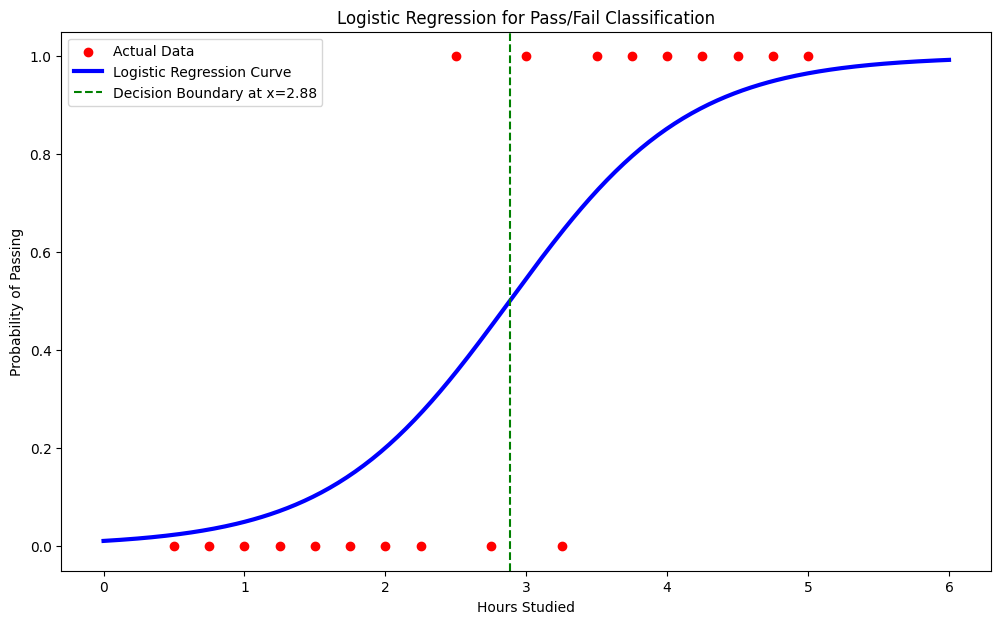

In [6]:
# Step 1: Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Step 2: Use the same dataset
hours_studied = np.array([0.5, 0.75, 1, 1.25, 1.5, 1.75, 2, 2.25, 2.5, 2.75, 3, 3.25, 3.5, 3.75, 4, 4.25, 4.5, 4.75, 5]).reshape(-1, 1)
pass_fail = np.array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1])

# For a more robust evaluation, we should split our data, but for this simple example, we'll train and test on the same data.

# Step 3: Create and train the Logistic Regression model
log_reg = LogisticRegression()
log_reg.fit(hours_studied, pass_fail)

# Step 4: Make predictions
# First, let's see the probabilities
# We will predict probabilities for the training data
# This will give us the probability of passing (class 1) for each hour studied
probabilities = log_reg.predict_proba(hours_studied)

# Then, let's see the final classifications (based on a 0.5 threshold)
# This will give us the predicted class (0 or 1) for each hour studied
predictions = log_reg.predict(hours_studied)

print("Let's examine a student who studied for 2.6 hours:")
study_time_example = np.array([[2.6]])
# Predict the probability and class for this example
# This will give us the probability of passing (class 1) for 2.6 hours studied
prob_example = log_reg.predict_proba(study_time_example)
# This will give us the predicted class (0 or 1) for 2.6 hours studied
pred_example = log_reg.predict(study_time_example)

print(f"Probability of Failing (Class 0) vs. Passing (Class 1): {prob_example[0]}")
print(f"Since {prob_example[0][1]:.2f} is > 0.5, the final classification is: {pred_example[0]} (Pass)")

# Step 5: Evaluate the model
accuracy = accuracy_score(pass_fail, predictions)
print(f"\nModel Accuracy on the training data: {accuracy * 100:.2f}%")

# Step 6: Visualize the result
plt.figure(figsize=(12, 7))
plt.scatter(hours_studied, pass_fail, color='red', zorder=20, label='Actual Data')

# Plot the sigmoid curve
x_test = np.linspace(0, 6, 300).reshape(-1, 1)
y_prob = log_reg.predict_proba(x_test)[:, 1] # Probability of class 1
plt.plot(x_test, y_prob, color='blue', linewidth=3, label='Logistic Regression Curve')

# Plot the decision boundary
# The decision boundary is where the probability of passing is 0.5
boundary = -log_reg.intercept_[0] / log_reg.coef_[0][0]
plt.axvline(x=boundary, color='green', linestyle='--', label=f'Decision Boundary at x={boundary:.2f}')

plt.ylabel('Probability of Passing')
plt.xlabel('Hours Studied')
plt.title('Logistic Regression for Pass/Fail Classification')
plt.legend()
plt.show()

---

## 6. Log-Loss Function (Cross-Entropy Loss)

### Introduction to Log-Loss

**Log-loss**, also known as **cross-entropy loss**, is the standard loss function used for evaluating the performance of classification models that output probabilities, such as logistic regression.

Log-loss measures how well the predicted probabilities match the actual class labels. It penalizes confident and incorrect predictions much more than less confident or correct ones.

#### The Formula

For a single binary classification example, the log-loss is defined as:

$$
\text{LogLoss} = -\left[ y \cdot \log(p) + (1 - y) \cdot \log(1 - p) \right]
$$

- $y$ is the true label (0 or 1)
- $p$ is the predicted probability that $y = 1$

For a dataset with $N$ samples, the average log-loss is:

$$
\text{LogLoss} = -\frac{1}{N} \sum_{i=1}^N \left[ y_i \cdot \log(p_i) + (1 - y_i) \cdot \log(1 - p_i) \right]
$$

In [7]:
def log_loss(y_true, y_prob):
    """
    Compute the log-loss (cross-entropy loss) for binary classification.

    Parameters:
    y_true (np.ndarray): True binary labels (0 or 1).
    y_prob (np.ndarray): Predicted probabilities for class 1.

    Returns:
    float: Log-loss value.
    """
    # Clip probabilities to avoid log(0)
    eps = 1e-15
    y_prob = np.clip(y_prob, eps, 1 - eps)
    loss = -np.mean(y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob))
    return loss

# Example usage with the logistic regression use case:
logloss_value = log_loss(pass_fail, probabilities[:, 1])
print(f"Log-loss (Cross Entropy Loss): {logloss_value:.4f}")

print("\nInterpretation of Log-loss:")
print(f"- The log-loss value of {logloss_value:.4f} quantifies how well the predicted probabilities from our logistic regression model match the actual pass/fail outcomes.")
print("- A lower log-loss indicates that the model's predicted probabilities are close to the true labels, meaning the model is well-calibrated and confident in its correct predictions.")
print("- In this case, the log-loss is quite low, suggesting that our model is making accurate and reliable probability estimates for student outcomes.")

Log-loss (Cross Entropy Loss): 0.2754

Interpretation of Log-loss:
- The log-loss value of 0.2754 quantifies how well the predicted probabilities from our logistic regression model match the actual pass/fail outcomes.
- A lower log-loss indicates that the model's predicted probabilities are close to the true labels, meaning the model is well-calibrated and confident in its correct predictions.
- In this case, the log-loss is quite low, suggesting that our model is making accurate and reliable probability estimates for student outcomes.


### Visualizing Log-Loss Penalty Curves

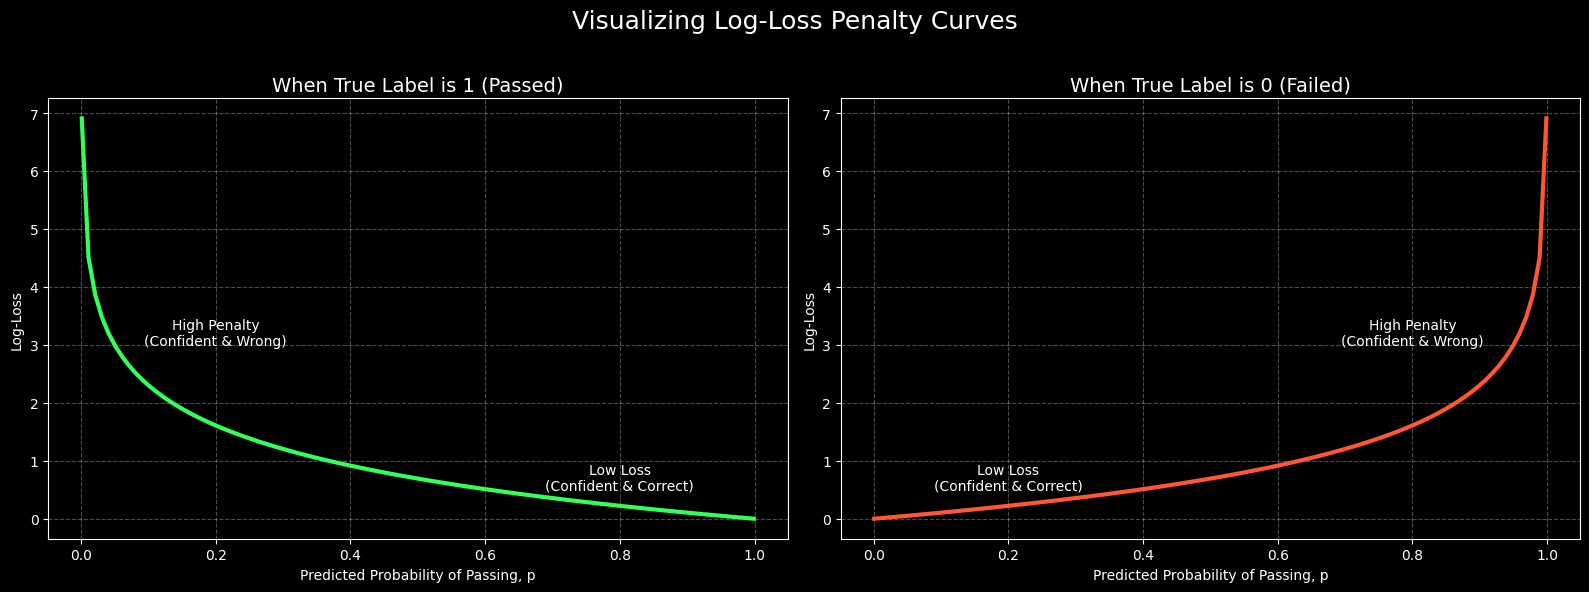

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Create a range of predicted probabilities from 0.001 to 0.999
p = np.linspace(0.001, 0.999, 100)

# Calculate the loss for each case
# Case 1: The true label is 1 (e.g., student Passed)
loss_for_y1 = -np.log(p)
# Case 2: The true label is 0 (e.g., student Failed)
loss_for_y0 = -np.log(1 - p)

# Create the plot
plt.style.use('dark_background')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Visualizing Log-Loss Penalty Curves', fontsize=18, color='white')

# Plot for y=1
ax1.plot(p, loss_for_y1, color='#33FF57', lw=3)
ax1.set_title('When True Label is 1 (Passed)', color='white', fontsize=14)
ax1.set_xlabel('Predicted Probability of Passing, p', color='white')
ax1.set_ylabel('Log-Loss', color='white')
ax1.tick_params(colors='white')
ax1.grid(True, linestyle='--', alpha=0.3)
ax1.text(0.8, 0.5, 'Low Loss\n(Confident & Correct)', ha='center', color='white')
ax1.text(0.2, 3.0, 'High Penalty\n(Confident & Wrong)', ha='center', color='white')

# Plot for y=0
ax2.plot(p, loss_for_y0, color='#FF5733', lw=3)
ax2.set_title('When True Label is 0 (Failed)', color='white', fontsize=14)
ax2.set_xlabel('Predicted Probability of Passing, p', color='white')
ax2.set_ylabel('Log-Loss', color='white')
ax2.tick_params(colors='white')
ax2.grid(True, linestyle='--', alpha=0.3)
ax2.text(0.2, 0.5, 'Low Loss\n(Confident & Correct)', ha='center', color='white')
ax2.text(0.8, 3.0, 'High Penalty\n(Confident & Wrong)', ha='center', color='white')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

---

## 7. Model Evaluation Metrics

Let's explore the key metrics for evaluating classification models.

In [9]:
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score

# Generate confusion matrix
cm = confusion_matrix(pass_fail, predictions)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(pass_fail, predictions, target_names=['Fail (0)', 'Pass (1)']))

# Calculate individual metrics
precision = precision_score(pass_fail, predictions)
recall = recall_score(pass_fail, predictions)
f1 = f1_score(pass_fail, predictions)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Confusion Matrix:
[[9 1]
 [1 8]]

Classification Report:
              precision    recall  f1-score   support

    Fail (0)       0.90      0.90      0.90        10
    Pass (1)       0.89      0.89      0.89         9

    accuracy                           0.89        19
   macro avg       0.89      0.89      0.89        19
weighted avg       0.89      0.89      0.89        19

Precision: 0.8889
Recall: 0.8889
F1-Score: 0.8889


### Understanding the Metrics

| Metric | Formula | Interpretation |
| :--- | :--- | :--- |
| **Accuracy** | (TP + TN) / (TP + TN + FP + FN) | Overall correctness of the model |
| **Precision** | TP / (TP + FP) | Of all predicted positives, how many are actually positive? |
| **Recall (Sensitivity)** | TP / (TP + FN) | Of all actual positives, how many did we predict correctly? |
| **F1-Score** | 2 × (Precision × Recall) / (Precision + Recall) | Harmonic mean of precision and recall |

---

## 📝 ASSIGNMENT TASKS

### Task 1: Implement Logistic Regression from Scratch (30 points)

1. **Implement the Sigmoid Function** - Create a function that implements the sigmoid formula: $\sigma(z) = \frac{1}{1 + e^{-z}}$

2. **Implement Log-Loss Function** - Create a function that calculates log-loss using the formula:
   $$
\text{LogLoss} = -\frac{1}{N} \sum_{i=1}^N \left[ y_i \cdot \log(p_i) + (1 - y_i) \cdot \log(1 - p_i) \right]
   $$

3. **Train a Logistic Regression Model** - Use scikit-learn to train a logistic regression model on the provided dataset.

4. **Evaluate the Model** - Calculate and display:
   - Accuracy
   - Precision
   - Recall
   - F1-Score
   - Log-Loss

### Task 2: Visualization (20 points)

1. **Plot the Sigmoid Curve** - Show the sigmoid function with the data points
2. **Plot the Decision Boundary** - Visualize where the model makes its classification decisions
3. **Plot Confusion Matrix** - Create a heatmap visualization of the confusion matrix

### Task 3: Analysis and Discussion (30 points)

Answer the following questions in markdown cells:

1. Why is logistic regression more suitable than linear regression for classification problems?
2. How does the threshold value affect classification? What happens if we change it from 0.5 to 0.7?
3. Explain the relationship between log-loss and model confidence. Why does log-loss penalize confident wrong predictions more?
4. When would you prioritize precision over recall, and vice versa?

### Task 4: Peer Review Activity (20 points)

Follow the in-class activity instructions:

1. **Code Review**: Swap notebooks with another group and review their implementation
2. **Questions**: Ask at least 3 questions about their code
3. **Feedback**: Provide constructive feedback on their implementation
4. **Documentation**: Document the peer review in your notebook

---

## 📤 Submission Guidelines

### What to Submit

1. **Jupyter Notebook** - Complete the assignment in this notebook file
2. **Report** - A separate report containing:
   - Group members and their roles
   - Summary of work done
   - Challenges faced and how you overcame them
   - Key learnings
   - Link to your GitHub repository
   - Link to peer group's repository (for peer review)

### Submission Deadline

**Date:** [To be filled by instructor]

### Grading Criteria

| Criterion | Points |
| :--- | :--- |
| Task 1: Implementation | 30 |
| Task 2: Visualization | 20 |
| Task 3: Analysis | 30 |
| Task 4: Peer Review | 20 |
| **Total** | **100** |

---

## 📚 References

1. Scikit-learn Documentation: Logistic Regression
2. Reference Repository: [GitHub Link]
3. Additional learning resources...

---

*This assignment was created for CSCN8010 - Machine Learning Fundamentals, Group 2*